<a href="https://colab.research.google.com/github/amavi-e/A-TinyML-Powered-Wearable-Navigation-Aid-for-the-Visually-Impaired/blob/preprocessing/preprocessing_visionImpaired.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q pycocotools opencv-python-headless

import os, cv2, json, shutil, random, glob
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("Ready")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready


In [2]:
BASE = '/content/drive/MyDrive/FYP/dataset'

OUTDOOR_TRAIN = f'{BASE}/26classes/train'
OUTDOOR_VAL   = f'{BASE}/26classes/valid'
OUTDOOR_TEST  = f'{BASE}/26classes/test'

INDOOR_TRAIN  = f'{BASE}/indoor-objects-detection-DatasetNinja/train'
INDOOR_VAL    = f'{BASE}/indoor-objects-detection-DatasetNinja/valid'
INDOOR_TEST   = f'{BASE}/indoor-objects-detection-DatasetNinja/test'

MOTS_IMAGES   = f'{BASE}/MOTSChallenge/train/images'
MOTS_ANN_TXT  = f'{BASE}/MOTSChallenge/train/instances_txt'

COCO_IMGS     = f'{BASE}/coco2017/train2017'
COCO_ANN      = f'{BASE}/coco2017/annotations/instances_train2017.json'

OUTPUT = '/content/drive/MyDrive/FYP/fyp-preprocessed'

import shutil as sh
if os.path.exists(OUTPUT):
    print("Deleting existing fyp-preprocessed folder...")
    sh.rmtree(OUTPUT)
    print("Deleted.")

for split in ['train', 'val', 'test']:
    os.makedirs(f'{OUTPUT}/{split}/images', exist_ok=True)
    os.makedirs(f'{OUTPUT}/{split}/labels', exist_ok=True)

print("Fresh fyp-preprocessed folder created")
print("\nChecking paths...")
for name, path in [
    ('Outdoor train', OUTDOOR_TRAIN),
    ('Indoor train',  INDOOR_TRAIN),
    ('MOTS images',   MOTS_IMAGES),
    ('COCO images',   COCO_IMGS),
    ('COCO ann',      COCO_ANN),
]:
    exists = os.path.exists(path)
    count  = len(os.listdir(path)) if exists and os.path.isdir(path) else '-'
    print(f"  {'✅' if exists else '❌'} {name}: {count} files")

Deleting existing fyp-preprocessed folder...
Deleted.
Fresh fyp-preprocessed folder created

Checking paths...
  ✅ Outdoor train: 32521 files
  ✅ Indoor train: 2 files
  ✅ MOTS images: 4 files
  ✅ COCO images: 30000 files
  ✅ COCO ann: - files


In [3]:
NAVIGATION_CLASSES = {
    # People
    'person':        0,
    # Vehicles
    'bicycle':       1,
    'car':           2,
    'motorcycle':    3,
    'bus':           4,
    'truck':         5,
    # Road objects
    'traffic light': 6,
    'stop sign':     7,
    'fire hydrant':  19,
    # Outdoor
    'bench':         8,
    'pole':          15,
    'stairs':        16,
    # Indoor furniture
    'chair':         9,
    'couch':         10,
    'table':         11,
    'door':          12,
    'window':        13,
    'cabinet':       14,
    'bed':           21,
    'toilet':        22,
    'sink':          23,
    'tv':            24,
    'potted plant':  25,
    'suitcase':      26,
    # Animals — specific (indoor AND outdoor)
    'dog':           17,
    'cat':           18,
    'bird':          27,
    # Animals — general
    'animal':        28,
    # General obstacle
    'object':        20,
}

SKIP_CLASSES = {
    'gun', 'Bushes', 'branch', 'rat',
    'boat', 'crosswalk', 'pothole',
    'elevator', 'cars-bikes-people', 'tree'
}

print(f"Total navigation classes: {len(NAVIGATION_CLASSES)}")
for idx, name in sorted((v,k) for k,v in NAVIGATION_CLASSES.items()):
    print(f"  {idx}: {name}")

Total navigation classes: 29
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: bus
  5: truck
  6: traffic light
  7: stop sign
  8: bench
  9: chair
  10: couch
  11: table
  12: door
  13: window
  14: cabinet
  15: pole
  16: stairs
  17: dog
  18: cat
  19: fire hydrant
  20: object
  21: bed
  22: toilet
  23: sink
  24: tv
  25: potted plant
  26: suitcase
  27: bird
  28: animal


In [4]:
def check_black_boxes(img, threshold=0.08):
    """Detect privacy redaction black boxes"""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    black_mask = (gray < 15).astype(np.uint8) * 255
    black_ratio = np.sum(black_mask > 0) / (img.shape[0] * img.shape[1])

    if black_ratio < 0.02:
        return False

    kernel = np.ones((20, 20), np.uint8)
    dilated = cv2.dilate(black_mask, kernel)
    contours, _ = cv2.findContours(
        dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    large_black_rects = 0
    img_area = img.shape[0] * img.shape[1]

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > img_area * 0.02:
            x, y, w, h = cv2.boundingRect(cnt)
            if area / (w * h) > 0.7:
                large_black_rects += 1

    return large_black_rects >= 2


def estimate_viewpoint(img):
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. White/plain background
    white_ratio = np.sum(gray > 230) / (h * w)
    if white_ratio > 0.45:
        return False, "studio/white background"

    # 2. Uniform background
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    sat_std = np.std(hsv[:, :, 1])
    if sat_std < 15:
        return False, "uniform/stock photo background"

    # 3. Edge density
    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(edges > 0) / (h * w)

    # 4. Blur check
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
    if blur_score < 8:
        return False, f"too blurry ({blur_score:.1f})"

    # 5. Extreme close-up
    corners = [
        gray[5:25,   5:25],
        gray[5:25,   w-25:w-5],
        gray[h-25:h-5, 5:25],
        gray[h-25:h-5, w-25:w-5]
    ]
    centre = gray[h//2-20:h//2+20, w//2-20:w//2+20]
    corner_means = [np.mean(c) for c in corners]
    centre_mean  = np.mean(centre)
    corner_diffs = [abs(cm - centre_mean) for cm in corner_means]
    if all(d < 20 for d in corner_diffs) and edge_density < 0.05:
        return False, "extreme close-up / fills frame"

    # 6. Top-down / aerial viewpoint — FIXED numpy unpacking
    lines = cv2.HoughLinesP(
        edges, 1, np.pi/180, 50,
        minLineLength=w*0.15, maxLineGap=20
    )

    if lines is not None and len(lines) > 8:
        angles = []
        for line in lines:
            # FIXED: safely extract coordinates
            try:
                pts = line[0]
                # Handle both array and scalar cases
                if hasattr(pts, '__len__') and len(pts) == 4:
                    x1 = int(pts[0])
                    y1 = int(pts[1])
                    x2 = int(pts[2])
                    y2 = int(pts[3])
                else:
                    continue

                if x2 - x1 == 0:
                    angles.append(90.0)
                else:
                    angle = abs(np.degrees(
                        np.arctan2(float(y2-y1), float(x2-x1))
                    ))
                    angles.append(min(angle, 180-angle))
            except (TypeError, ValueError, IndexError):
                continue

        if len(angles) > 0:
            angles     = np.array(angles)
            horizontal = np.sum(angles < 15) / len(angles)
            vertical   = np.sum(angles > 75) / len(angles)
            if horizontal > 0.80 and vertical < 0.05:
                return False, "top-down/aerial viewpoint"

    # 7. Extreme upward angle
    top_brightness    = np.mean(gray[:h//3, :])
    bottom_brightness = np.mean(gray[2*h//3:, :])
    if bottom_brightness > top_brightness * 2.0 and top_brightness < 60:
        return False, "extreme upward angle"

    # 8. Extreme tilt
    if lines is not None and len(lines) > 8:
        angles = []
        for line in lines:
            try:
                pts = line[0]
                if hasattr(pts, '__len__') and len(pts) == 4:
                    x1 = int(pts[0])
                    y1 = int(pts[1])
                    x2 = int(pts[2])
                    y2 = int(pts[3])
                else:
                    continue
                if x2 - x1 == 0:
                    angles.append(90.0)
                else:
                    angle = abs(np.degrees(
                        np.arctan2(float(y2-y1), float(x2-x1))
                    ))
                    angles.append(min(angle, 180-angle))
            except (TypeError, ValueError, IndexError):
                continue

        if len(angles) > 0:
            angles   = np.array(angles)
            diagonal = np.sum((angles > 30) & (angles < 60)) / len(angles)
            if diagonal > 0.75:
                return False, "extreme tilt/diagonal"

    # 9. Stock photo style
    border_region = np.concatenate([
        gray[:20, :].flatten(),
        gray[-20:, :].flatten(),
        gray[:, :20].flatten(),
        gray[:, -20:].flatten()
    ])
    centre_region = gray[h//4:3*h//4, w//4:3*w//4].flatten()
    border_std    = np.std(border_region)
    centre_std    = np.std(centre_region)
    if border_std < 12 and centre_std > 40 and white_ratio > 0.25:
        return False, "stock photo style"

    return True, "ok"


def is_valid_image(img_path, min_brightness=18):
    """Full image validation"""
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            return False, "corrupted"

        h, w = img.shape[:2]
        if h < 96 or w < 96:
            return False, f"too small {w}x{h}"

        gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness = np.mean(gray)

        if brightness < min_brightness:
            return False, f"too dark {brightness:.1f}"

        if check_black_boxes(img):
            return False, "privacy redaction boxes"

        valid, reason = estimate_viewpoint(img)
        if not valid:
            return False, reason

        return True, "ok"

    except Exception as e:
        return False, f"error: {str(e)[:50]}"


print("Validation functions updated — numpy unpacking fixed")


def resize_pad(img, size=320):
    """Resize with letterbox padding"""
    h, w = img.shape[:2]
    scale = size / max(h, w)
    nh, nw = int(h * scale), int(w * scale)
    resized = cv2.resize(img, (nw, nh))
    ph, pw = size - nh, size - nw
    return cv2.copyMakeBorder(
        resized,
        ph//2, ph-ph//2,
        pw//2, pw-pw//2,
        cv2.BORDER_CONSTANT, value=(114, 114, 114)
    )

print("Validation functions ready")
print("Filters: white bg, stock photo, close-up, aerial,")
print("         upward angle, tilt, blurry, black boxes")

Validation functions updated — numpy unpacking fixed
Validation functions ready
Filters: white bg, stock photo, close-up, aerial,
         upward angle, tilt, blurry, black boxes


In [5]:
def process_indoor(split_dir, output_split):
    indoor_to_nav = {
        'door':        'door',
        'openedDoor':  'door',
        'window':      'window',
        'chair':       'chair',
        'table':       'table',
        'cabinet':     'cabinet',
        'couch':       'couch',
        'pole':        'pole',
        'bed':         'bed',
        'sink':        'sink',
        'toilet':      'toilet',
        'tv':          'tv',
        'sofa':        'couch',
        'wardrobe':    'cabinet',
        'dog':         'dog',
        'cat':         'cat',
        'bird':        'bird',
    }

    img_dir = Path(split_dir) / 'img'
    ann_dir = Path(split_dir) / 'ann'

    if not img_dir.exists():
        print(f"  Not found: {img_dir}")
        return 0

    img_files = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    saved = 0
    skip_reasons = {}

    for img_path in img_files:
        ann_path = ann_dir / (img_path.name + '.json')
        if not ann_path.exists():
            skip_reasons['no annotation'] = skip_reasons.get('no annotation', 0) + 1
            continue

        valid, reason = is_valid_image(img_path)
        if not valid:
            skip_reasons[reason] = skip_reasons.get(reason, 0) + 1
            continue

        with open(ann_path) as f:
            ann = json.load(f)

        iw = ann['size']['width']
        ih = ann['size']['height']
        labels = []

        for obj in ann['objects']:
            try:
                title = obj['classTitle']
                if title not in indoor_to_nav:
                    continue

                nav    = indoor_to_nav[title]
                cls_id = NAVIGATION_CLASSES[nav]

                pts = obj['points']['exterior']

                # FIXED: Handle different point formats
                # Format 1: [[x1,y1],[x2,y2]] — rectangle
                # Format 2: [[x1,y1],[x2,y2],[x3,y3]...] — polygon
                # Format 3: numpy arrays

                if len(pts) < 2:
                    continue

                # Convert all points to float safely
                all_x = []
                all_y = []

                for pt in pts:
                    try:
                        if hasattr(pt, '__len__') and len(pt) >= 2:
                            all_x.append(float(pt[0]))
                            all_y.append(float(pt[1]))
                        elif hasattr(pt, 'item'):
                            # numpy scalar — skip
                            continue
                    except (TypeError, ValueError, IndexError):
                        continue

                if len(all_x) < 2 or len(all_y) < 2:
                    continue

                # Get bounding box from all points
                x1 = min(all_x)
                x2 = max(all_x)
                y1 = min(all_y)
                y2 = max(all_y)

                # Convert to YOLO format
                cx = ((x1 + x2) / 2) / iw
                cy = ((y1 + y2) / 2) / ih
                bw = abs(x2 - x1) / iw
                bh = abs(y2 - y1) / ih

                obj_area = bw * bh
                if obj_area < 0.003:
                    continue
                if obj_area > 0.88:
                    continue
                if bw < 0.02 or bh < 0.02:
                    continue

                cx = min(max(cx, 0), 1)
                cy = min(max(cy, 0), 1)
                bw = min(bw, 1)
                bh = min(bh, 1)

                labels.append(
                    f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"
                )

            except Exception as e:
                skip_reasons[f'parse error'] = skip_reasons.get('parse error', 0) + 1
                continue

        if not labels:
            skip_reasons['no valid labels'] = skip_reasons.get('no valid labels', 0) + 1
            continue

        img = cv2.imread(str(img_path))
        img_r = resize_pad(img)
        fname = f"indoor_{img_path.stem}.jpg"
        cv2.imwrite(f"{OUTPUT}/{output_split}/images/{fname}", img_r)
        with open(
            f"{OUTPUT}/{output_split}/labels/{fname.replace('.jpg','.txt')}", 'w'
        ) as f:
            f.write('\n'.join(labels))

        saved += 1

    print(f"  {output_split}: saved={saved}, "
          f"skipped={sum(skip_reasons.values())}")
    print(f"  Skip reasons: {skip_reasons}")
    return saved


print("Processing Indoor dataset...")
t = process_indoor(INDOOR_TRAIN, 'train')
v = process_indoor(INDOOR_VAL,   'val')
e = process_indoor(INDOOR_TEST,  'test')
print(f"Indoor total: {t+v+e}")

Processing Indoor dataset...
  train: saved=547, skipped=432
  Skip reasons: {'too dark 16.2': 1, 'no valid labels': 333, 'uniform/stock photo background': 14, 'extreme close-up / fills frame': 6, 'extreme upward angle': 7, 'privacy redaction boxes': 32, 'studio/white background': 34, 'too blurry (7.3)': 1, 'too blurry (3.3)': 1, 'stock photo style': 1, 'too blurry (5.6)': 1, 'too blurry (4.7)': 1}
  val: saved=110, skipped=112
  Skip reasons: {'too dark 12.2': 1, 'privacy redaction boxes': 9, 'uniform/stock photo background': 6, 'no valid labels': 84, 'studio/white background': 8, 'too blurry (2.4)': 1, 'stock photo style': 1, 'too blurry (3.7)': 1, 'extreme close-up / fills frame': 1}
  test: saved=89, skipped=18
  Skip reasons: {'privacy redaction boxes': 12, 'extreme upward angle': 1, 'no valid labels': 5}
Indoor total: 746


In [6]:
def process_outdoor_coco(split_dir, output_split, max_images=35000):
    """
    26classes Roboflow — COCO JSON format
    Dogs and cats detected in outdoor scenes too
    """
    split_path = Path(split_dir)
    ann_file   = split_path / '_annotations.coco.json'

    if not ann_file.exists():
        print(f"  Not found: {ann_file}")
        return 0

    outdoor_to_nav = {
        # People
        'person':        'person',
        'Person':        'person',
        # Vehicles
        'bicycle':       'bicycle',
        'car':           'car',
        'motorcycle':    'motorcycle',
        'Bus':           'bus',
        'bus':           'bus',
        'Truck':         'truck',
        'truck':         'truck',
        # Road objects
        'bench':         'bench',
        'chair':         'chair',
        'door':          'door',
        'stairs':        'stairs',
        'stop_sign':     'stop sign',
        'fire_hydrant':  'fire hydrant',
        'traffic light': 'traffic light',
        'green_light':   'traffic light',
        'red_light':     'traffic light',
        'yellow_light':  'traffic light',
        'traffic_cone':  'object',
        'train':         'object',
        # Animals — specific (indoor AND outdoor)
        'dog':           'dog',
        'cat':           'cat',
        'bird':          'bird',
        # Animals — general
        'horse':         'animal',
        'cow':           'animal',
        'sheep':         'animal',
        'elephant':      'animal',
        'bear':          'animal',
        'zebra':         'animal',
        'giraffe':       'animal',
    }

    print(f"  Loading {ann_file.name}...")
    with open(ann_file) as f:
        coco_data = json.load(f)

    id_to_file = {img['id']: img['file_name'] for img in coco_data['images']}
    id_to_cat  = {cat['id']: cat['name'] for cat in coco_data['categories']}

    img_anns = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in img_anns:
            img_anns[img_id] = []
        img_anns[img_id].append(ann)

    all_ids = list(img_anns.keys())
    random.shuffle(all_ids)
    all_ids = all_ids[:max_images]

    print(f"  Processing {len(all_ids)} images...")

    saved = 0
    skip_reasons = {}

    for i, img_id in enumerate(all_ids):
        fname = id_to_file.get(img_id)
        if not fname:
            skip_reasons['no filename'] = skip_reasons.get('no filename', 0) + 1
            continue

        img_path = split_path / fname
        if not img_path.exists():
            skip_reasons['file missing'] = skip_reasons.get('file missing', 0) + 1
            continue

        valid, reason = is_valid_image(img_path)
        if not valid:
            skip_reasons[reason] = skip_reasons.get(reason, 0) + 1
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            skip_reasons['cv2 fail'] = skip_reasons.get('cv2 fail', 0) + 1
            continue

        ih, iw = img.shape[:2]
        labels = []

        for ann in img_anns[img_id]:
            cat_name = id_to_cat.get(ann['category_id'], '')

            if cat_name in SKIP_CLASSES:
                continue

            nav_name = outdoor_to_nav.get(cat_name, 'object')
            cls_id   = NAVIGATION_CLASSES[nav_name]

            x, y, bw, bh = ann['bbox']
            cx = (x + bw/2) / iw
            cy = (y + bh/2) / ih
            nw = bw / iw
            nh = bh / ih

            obj_area = nw * nh
            if obj_area < 0.003:
                continue
            if obj_area > 0.88:
                continue
            if nw < 0.02 or nh < 0.02:
                continue

            cx = min(max(cx, 0), 1)
            cy = min(max(cy, 0), 1)
            nw = min(nw, 1)
            nh = min(nh, 1)
            labels.append(
                f"{cls_id} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}"
            )

        if not labels:
            skip_reasons['no valid labels'] = skip_reasons.get('no valid labels', 0) + 1
            continue

        img_r = resize_pad(img)
        out_fname = f"outdoor_{Path(fname).stem}.jpg"
        cv2.imwrite(f"{OUTPUT}/{output_split}/images/{out_fname}", img_r)
        with open(
            f"{OUTPUT}/{output_split}/labels/{out_fname.replace('.jpg','.txt')}", 'w'
        ) as f:
            f.write('\n'.join(labels))

        saved += 1

        if (i+1) % 1000 == 0:
            print(f"    {i+1}/{len(all_ids)} — saved: {saved}")

    print(f"  {output_split}: saved={saved}, "
          f"skipped={sum(skip_reasons.values())}")
    print(f"  Skip reasons: {skip_reasons}")
    return saved


print("Processing Outdoor 26classes dataset...")
t = process_outdoor_coco(OUTDOOR_TRAIN, 'train', max_images=35000)
v = process_outdoor_coco(OUTDOOR_VAL,   'val',   max_images=3000)
e = process_outdoor_coco(OUTDOOR_TEST,  'test',  max_images=1500)
print(f"Outdoor total: {t+v+e}")

Processing Outdoor 26classes dataset...
  Loading _annotations.coco.json...
  Processing 31944 images...
    1000/31944 — saved: 560
    3000/31944 — saved: 1705
    6000/31944 — saved: 3481
    8000/31944 — saved: 4642
    11000/31944 — saved: 6388
    15000/31944 — saved: 8663
    17000/31944 — saved: 9850
    21000/31944 — saved: 12089
    22000/31944 — saved: 12653
    23000/31944 — saved: 13187
    24000/31944 — saved: 13761
    25000/31944 — saved: 14343
    26000/31944 — saved: 14929
    28000/31944 — saved: 16054
    29000/31944 — saved: 16622
  train: saved=18296, skipped=13648
  Skip reasons: {'studio/white background': 2130, 'no valid labels': 8582, 'privacy redaction boxes': 712, 'extreme upward angle': 931, 'uniform/stock photo background': 1199, 'too dark 17.8': 2, 'too dark 16.6': 1, 'too dark 12.0': 2, 'extreme close-up / fills frame': 39, 'too dark 8.2': 2, 'too dark 15.3': 1, 'too dark 11.9': 1, 'too dark 12.9': 1, 'too dark 8.1': 1, 'too dark 9.5': 2, 'stock photo st

In [7]:
def decode_rle_bbox(rle_str, height, width):
    """Decode MOTS RLE to YOLO bounding box"""
    try:
        from pycocotools import mask as mask_util
        rle = {'counts': rle_str.encode(), 'size': [height, width]}
        decoded = mask_util.decode(rle)
        rows = np.any(decoded, axis=1)
        cols = np.any(decoded, axis=0)
        if not rows.any() or not cols.any():
            return None
        y1, y2 = np.where(rows)[0][[0,-1]]
        x1, x2 = np.where(cols)[0][[0,-1]]
        cx = ((x1+x2)/2) / width
        cy = ((y1+y2)/2) / height
        bw = (x2-x1) / width
        bh = (y2-y1) / height
        return cx, cy, bw, bh
    except:
        return None


def process_mots(images_dir, ann_txt_dir, max_per_seq=200):
    """
    MOTS: images in images/0002,0005,0009,0011
    Annotations: instances_txt/0002.txt etc
    Class 2=person, Class 10=car
    """
    sequences = ['0002', '0005', '0009', '0011']
    total = 0

    for seq in sequences:
        img_seq_dir = Path(images_dir) / seq
        ann_file = Path(ann_txt_dir) / f'{seq}.txt'

        if not img_seq_dir.exists() or not ann_file.exists():
            print(f"  Sequence {seq} not found")
            continue

        print(f"  Processing sequence {seq}...")

        # Parse annotations
        frame_anns = {}
        with open(ann_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 6:
                    continue
                frame_id = int(parts[0])
                cls_id = int(parts[2])
                h = int(parts[3])
                w = int(parts[4])
                rle = parts[5]

                if cls_id == 2:
                    nav_cls = 0   # person
                elif cls_id == 10:
                    nav_cls = 2   # car
                else:
                    continue

                bbox = decode_rle_bbox(rle, h, w)
                if bbox is None:
                    continue

                if frame_id not in frame_anns:
                    frame_anns[frame_id] = []
                frame_anns[frame_id].append((nav_cls, *bbox))

        img_files = sorted(
            list(img_seq_dir.glob('*.png')) +
            list(img_seq_dir.glob('*.jpg'))
        )[:max_per_seq]

        saved = skipped = 0
        for img_path in img_files:
            frame_id = int(img_path.stem)
            if frame_id not in frame_anns:
                skipped += 1
                continue

            valid, reason = is_valid_image(img_path)
            if not valid:
                skipped += 1
                continue

            img = cv2.imread(str(img_path))
            if img is None:
                skipped += 1
                continue

            labels = []
            for ann in frame_anns[frame_id]:
                cls, cx, cy, bw, bh = ann
                if bw > 0.01 and bh > 0.01:
                    labels.append(f"{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

            if not labels:
                skipped += 1
                continue

            img_r = resize_pad(img)
            fname = f"mots_{seq}_{img_path.stem}.jpg"
            cv2.imwrite(f"{OUTPUT}/train/images/{fname}", img_r)
            with open(f"{OUTPUT}/train/labels/{fname.replace('.jpg','.txt')}", 'w') as f:
                f.write('\n'.join(labels))

            saved += 1

        print(f"    seq {seq}: saved={saved}, skipped={skipped}")
        total += saved

    print(f"MOTS total: {total}")
    return total


print("Processing MOTS dataset...")
mots_total = process_mots(MOTS_IMAGES, MOTS_ANN_TXT)

Processing MOTS dataset...
  Processing sequence 0002...
    seq 0002: saved=200, skipped=0
  Processing sequence 0005...
    seq 0005: saved=167, skipped=33
  Processing sequence 0009...
    seq 0009: saved=200, skipped=0
  Processing sequence 0011...
    seq 0011: saved=200, skipped=0
MOTS total: 767


In [8]:
def process_coco(coco_img_dir, coco_ann_file, output_split,
                  max_images=20000, target_size=320):
    """
    COCO 2017 — handles both indoor and outdoor scenes
    Dogs and cats detected regardless of scene type
    """
    from pycocotools.coco import COCO

    coco_to_nav = {
        # People and vehicles
        'person':        'person',
        'bicycle':       'bicycle',
        'car':           'car',
        'motorcycle':    'motorcycle',
        'bus':           'bus',
        'truck':         'truck',
        'traffic light': 'traffic light',
        'stop sign':     'stop sign',
        'fire hydrant':  'fire hydrant',
        # Outdoor
        'bench':         'bench',
        'stairs':        'stairs',
        # Indoor furniture
        'chair':         'chair',
        'couch':         'couch',
        'dining table':  'table',
        'door':          'door',
        'window':        'window',
        'bed':           'bed',
        'toilet':        'toilet',
        'sink':          'sink',
        'tv':            'tv',
        'potted plant':  'potted plant',
        'suitcase':      'suitcase',
        # Animals — specific (indoor AND outdoor)
        'dog':           'dog',
        'cat':           'cat',
        'bird':          'bird',
        # Animals — general
        'horse':         'animal',
        'cow':           'animal',
        'sheep':         'animal',
        'elephant':      'animal',
        'bear':          'animal',
        'zebra':         'animal',
        'giraffe':       'animal',
        # General obstacles
        'laptop':        'object',
        'backpack':      'object',
        'refrigerator':  'object',
        'oven':          'object',
        'microwave':     'object',
        'book':          'object',
        'clock':         'object',
        'vase':          'object',
        'umbrella':      'object',
        'handbag':       'object',
    }

    print(f"  Loading COCO annotations...")
    coco = COCO(coco_ann_file)

    all_cats    = coco.loadCats(coco.getCatIds())
    coco_to_cls = {}

    for cat in all_cats:
        name = cat['name'].lower()
        # Check both exact and lowercase match
        for coco_name, nav_name in coco_to_nav.items():
            if name == coco_name.lower():
                if nav_name in NAVIGATION_CLASSES:
                    coco_to_cls[cat['id']] = NAVIGATION_CLASSES[nav_name]
                break

    print(f"  Matched {len(coco_to_cls)} COCO categories")

    # Show matched categories
    matched_cats = coco.loadCats(list(coco_to_cls.keys()))
    for c in sorted(matched_cats, key=lambda x: x['name']):
        nav_cls = coco_to_cls[c['id']]
        nav_name = {v: k for k,v in NAVIGATION_CLASSES.items()}[nav_cls]
        print(f"    {c['name']:20s} → {nav_name}")

    # Get image IDs
    img_ids = set()
    for coco_cat_id in coco_to_cls.keys():
        ids = coco.getImgIds(catIds=[coco_cat_id])
        img_ids.update(ids)

    img_ids = list(img_ids)
    random.shuffle(img_ids)
    img_ids = img_ids[:max_images]
    print(f"  Processing {len(img_ids)} images...")

    saved = 0
    skip_reasons = {}

    for i, img_id in enumerate(img_ids):
        img_info = coco.loadImgs(img_id)[0]
        img_path = Path(coco_img_dir) / img_info['file_name']

        if not img_path.exists():
            skip_reasons['file missing'] = skip_reasons.get('file missing', 0) + 1
            continue

        valid, reason = is_valid_image(img_path)
        if not valid:
            skip_reasons[reason] = skip_reasons.get(reason, 0) + 1
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            skip_reasons['cv2 fail'] = skip_reasons.get('cv2 fail', 0) + 1
            continue

        orig_h, orig_w = img.shape[:2]

        ann_ids = coco.getAnnIds(
            imgIds=img_id,
            catIds=list(coco_to_cls.keys())
        )
        anns = coco.loadAnns(ann_ids)

        if not anns:
            skip_reasons['no annotations'] = skip_reasons.get('no annotations', 0) + 1
            continue

        labels = []

        for ann in anns:
            if ann['category_id'] not in coco_to_cls:
                continue

            cls_id       = coco_to_cls[ann['category_id']]
            x, y, bw, bh = ann['bbox']

            cx = (x + bw/2) / orig_w
            cy = (y + bh/2) / orig_h
            nw = bw / orig_w
            nh = bh / orig_h

            obj_area = nw * nh
            if obj_area < 0.003:
                continue
            if obj_area > 0.88:
                continue
            if nw < 0.02 or nh < 0.02:
                continue

            cx = min(max(cx, 0), 1)
            cy = min(max(cy, 0), 1)
            nw = min(nw, 1)
            nh = min(nh, 1)
            labels.append(
                f"{cls_id} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}"
            )

        if not labels:
            skip_reasons['no valid labels'] = skip_reasons.get('no valid labels', 0) + 1
            continue

        img_r  = resize_pad(img, target_size)
        fname  = f"coco_{img_info['file_name']}"
        cv2.imwrite(f"{OUTPUT}/{output_split}/images/{fname}", img_r)
        with open(
            f"{OUTPUT}/{output_split}/labels/{fname.replace('.jpg','.txt')}", 'w'
        ) as f:
            f.write('\n'.join(labels))

        saved += 1

        if (i+1) % 1000 == 0:
            print(f"    {i+1}/{len(img_ids)} — saved: {saved}")

    print(f"  {output_split}: saved={saved}, "
          f"skipped={sum(skip_reasons.values())}")
    print(f"  Skip reasons: {skip_reasons}")
    return saved


print("Processing COCO 2017 dataset...")
coco_t = process_coco(COCO_IMGS, COCO_ANN, 'train', max_images=20000)
coco_v = process_coco(COCO_IMGS, COCO_ANN, 'val',   max_images=3000)
coco_e = process_coco(COCO_IMGS, COCO_ANN, 'test',  max_images=1500)
print(f"COCO total: {coco_t+coco_v+coco_e}")

Processing COCO 2017 dataset...
  Loading COCO annotations...
loading annotations into memory...
Done (t=22.18s)
creating index...
index created!
  Matched 39 COCO categories
    backpack             → object
    bear                 → animal
    bed                  → bed
    bench                → bench
    bicycle              → bicycle
    bird                 → bird
    book                 → object
    bus                  → bus
    car                  → car
    cat                  → cat
    chair                → chair
    clock                → object
    couch                → couch
    cow                  → animal
    dining table         → table
    dog                  → dog
    elephant             → animal
    fire hydrant         → fire hydrant
    giraffe              → animal
    handbag              → object
    horse                → animal
    laptop               → object
    microwave            → object
    motorcycle           → motorcycle
    oven           

In [9]:
train_n = len(os.listdir(f'{OUTPUT}/train/images'))
val_n   = len(os.listdir(f'{OUTPUT}/val/images'))
test_n  = len(os.listdir(f'{OUTPUT}/test/images'))

print("=" * 45)
print("PREPROCESSING COMPLETE")
print("=" * 45)
print(f"Train : {train_n}")
print(f"Val   : {val_n}")
print(f"Test  : {test_n}")
print(f"Total : {train_n + val_n + test_n}")
print("=" * 45)

# Source breakdown
prefixes = {
    'indoor': 0, 'outdoor': 0,
    'mots': 0,   'coco': 0, 'other': 0
}
for f in os.listdir(f'{OUTPUT}/train/images'):
    matched = False
    for prefix in ['indoor', 'outdoor', 'mots', 'coco']:
        if f.startswith(prefix):
            prefixes[prefix] += 1
            matched = True
            break
    if not matched:
        prefixes['other'] += 1

print("\nTrain source breakdown:")
for src, count in prefixes.items():
    if count > 0:
        pct = count / train_n * 100
        print(f"  {src:10s}: {count:,} ({pct:.1f}%)")

# Consistency check
train_lbls = len(os.listdir(f'{OUTPUT}/train/labels'))
val_lbls   = len(os.listdir(f'{OUTPUT}/val/labels'))
test_lbls  = len(os.listdir(f'{OUTPUT}/test/labels'))

print("\nConsistency check:")
print(f"  Train : {'✅' if train_n == train_lbls else '❌'} "
      f"({train_n} images, {train_lbls} labels)")
print(f"  Val   : {'✅' if val_n == val_lbls else '❌'} "
      f"({val_n} images, {val_lbls} labels)")
print(f"  Test  : {'✅' if test_n == test_lbls else '❌'} "
      f"({test_n} images, {test_lbls} labels)")

# Class distribution in training set
print("\nClass distribution in train labels:")
class_names = {v: k for k, v in NAVIGATION_CLASSES.items()}
class_counts = {name: 0 for name in NAVIGATION_CLASSES}

for fname in os.listdir(f'{OUTPUT}/train/labels'):
    with open(f'{OUTPUT}/train/labels/{fname}') as f:
        for line in f:
            if line.strip():
                cls_id = int(line.split()[0])
                cls_name = class_names.get(cls_id, 'unknown')
                if cls_name in class_counts:
                    class_counts[cls_name] += 1

class_counts = {k: v for k, v in class_counts.items() if v > 0}
for name, count in sorted(
    class_counts.items(), key=lambda x: x[1], reverse=True
):
    print(f"  {name:20s}: {count:,}")

# Save YAML
NC_actual = len(NAVIGATION_CLASSES)
yaml = f"""path: {OUTPUT}
train: train/images
val: val/images
test: test/images
nc: {NC_actual}
names:
"""
for idx, name in sorted((v, k) for k, v in NAVIGATION_CLASSES.items()):
    yaml += f"  {idx}: {name}\n"

with open(f'{OUTPUT}/dataset.yaml', 'w') as f:
    f.write(yaml)

print(f"\ndataset.yaml saved with {NC_actual} classes")

PREPROCESSING COMPLETE
Train : 24301
Val   : 2497
Test  : 1263
Total : 28061

Train source breakdown:
  indoor    : 547 (2.3%)
  outdoor   : 18,296 (75.3%)
  mots      : 767 (3.2%)
  coco      : 4,691 (19.3%)

Consistency check:
  Train : ✅ (24301 images, 24301 labels)
  Val   : ✅ (2497 images, 2497 labels)
  Test  : ✅ (1263 images, 1263 labels)

Class distribution in train labels:
  person              : 21,254
  object              : 8,412
  car                 : 5,239
  traffic light       : 5,100
  bicycle             : 2,470
  bus                 : 2,298
  door                : 2,062
  chair               : 1,878
  motorcycle          : 1,597
  fire hydrant        : 1,521
  stop sign           : 1,454
  animal              : 1,336
  table               : 862
  truck               : 619
  stairs              : 509
  bench               : 416
  potted plant        : 349
  window              : 343
  couch               : 330
  suitcase            : 321
  dog                 : 284
  

SECTION 1: KEPT IMAGES


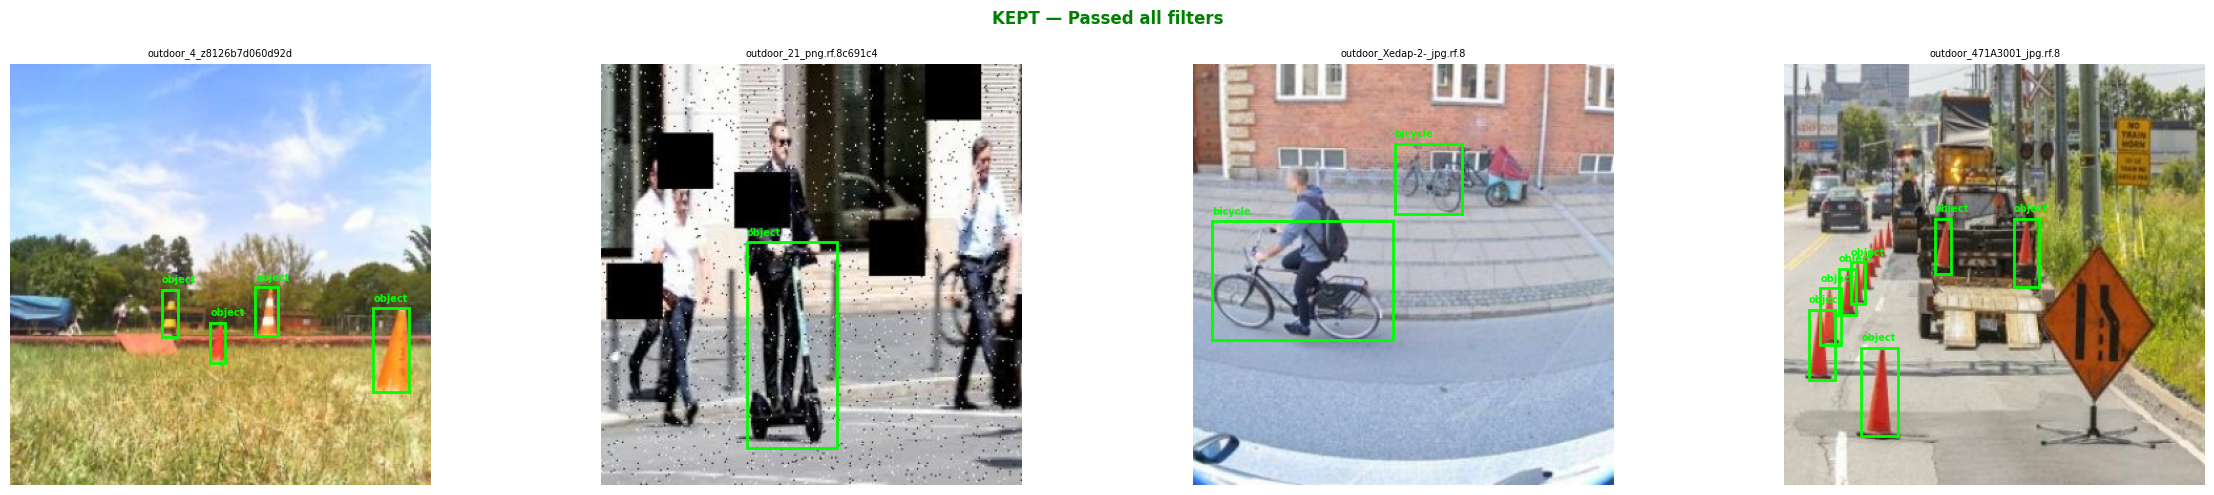


SECTION 2: REMOVED IMAGES


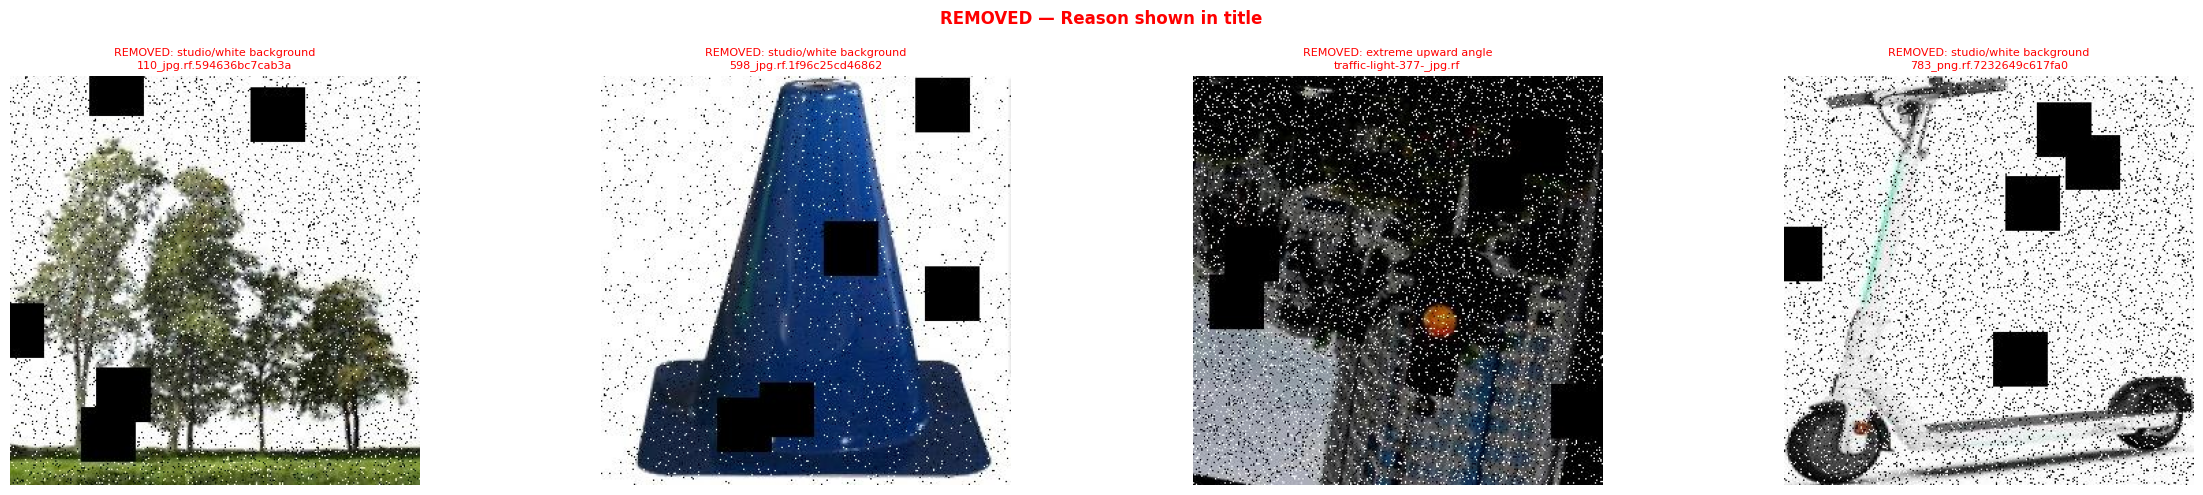

In [10]:
def show_validation_samples(n_kept=4, n_removed=4):
    """Show kept and removed samples with reasons"""

    class_names = {v: k for k, v in NAVIGATION_CLASSES.items()}

    def draw_boxes(img, label_path):
        img_draw = img.copy()
        h, w = img_draw.shape[:2]
        if os.path.exists(str(label_path)):
            with open(label_path) as f:
                for line in f:
                    p = line.strip().split()
                    if len(p) == 5:
                        cls = int(p[0])
                        cx, cy = float(p[1]), float(p[2])
                        bw, bh = float(p[3]), float(p[4])
                        x1 = int((cx-bw/2)*w)
                        y1 = int((cy-bh/2)*h)
                        x2 = int((cx+bw/2)*w)
                        y2 = int((cy+bh/2)*h)
                        cv2.rectangle(img_draw, (x1,y1), (x2,y2),
                                      (0,255,0), 2)
                        axes[i].text(
                            x1, max(y1-5,10),
                            class_names.get(cls, str(cls)),
                            color='lime', fontsize=7, weight='bold'
                        )
        return img_draw

    # ── Section 1: Kept images ────────────────────────────────────────────
    print("SECTION 1: KEPT IMAGES")
    img_dir = f'{OUTPUT}/train/images'
    lbl_dir = f'{OUTPUT}/train/labels'
    files   = os.listdir(img_dir)
    samples = random.sample(files, min(n_kept, len(files)))

    fig, axes = plt.subplots(1, len(samples), figsize=(6*len(samples), 5))
    if len(samples) == 1:
        axes = [axes]
    fig.suptitle('KEPT — Passed all filters', color='green',
                 fontsize=12, weight='bold')

    for i, fname in enumerate(samples):
        img = cv2.imread(f'{img_dir}/{fname}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        lbl = f'{lbl_dir}/{fname.replace(".jpg",".txt")}'

        axes[i].imshow(img)

        if os.path.exists(lbl):
            h, w = img.shape[:2]
            with open(lbl) as f:
                for line in f:
                    p = line.strip().split()
                    if len(p) == 5:
                        cls = int(p[0])
                        cx,cy,bw,bh = float(p[1]),float(p[2]),\
                                       float(p[3]),float(p[4])
                        x1 = int((cx-bw/2)*w)
                        y1 = int((cy-bh/2)*h)
                        import matplotlib.patches as patches
                        rect = patches.Rectangle(
                            (x1,y1), int(bw*w), int(bh*h),
                            linewidth=2, edgecolor='lime',
                            facecolor='none'
                        )
                        axes[i].add_patch(rect)
                        axes[i].text(
                            x1, max(y1-5,10),
                            class_names.get(cls, str(cls)),
                            color='lime', fontsize=7, weight='bold'
                        )

        axes[i].set_title(fname[:25], fontsize=7)
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT}/kept_samples.png',
                dpi=120, bbox_inches='tight')
    plt.show()

    # ── Section 2: Removed images with reasons ────────────────────────────
    print("\nSECTION 2: REMOVED IMAGES")
    removed = []
    test_sources = []

    for d in [OUTDOOR_TRAIN, INDOOR_TRAIN]:
        files = [f for f in os.listdir(d)
                 if f.endswith(('.jpg','.png'))]
        test_sources.extend([
            os.path.join(d, f)
            for f in random.sample(files, min(100, len(files)))
        ])

    for img_path in test_sources:
        valid, reason = is_valid_image(img_path)
        if not valid:
            removed.append((img_path, reason))
        if len(removed) >= n_removed:
            break

    if removed:
        fig, axes = plt.subplots(
            1, len(removed), figsize=(6*len(removed), 5)
        )
        if len(removed) == 1:
            axes = [axes]
        fig.suptitle('REMOVED — Reason shown in title',
                     color='red', fontsize=12, weight='bold')

        for i, (img_path, reason) in enumerate(removed):
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i].imshow(img)
            axes[i].set_title(
                f'REMOVED: {reason}\n{Path(img_path).name[:25]}',
                fontsize=8, color='red'
            )
            axes[i].axis('off')

        plt.tight_layout()
        plt.savefig(f'{OUTPUT}/removed_samples.png',
                    dpi=120, bbox_inches='tight')
        plt.show()
    else:
        print("No removed images found in sample")


show_validation_samples(n_kept=4, n_removed=4)

In [11]:
import os

OUTPUT = '/content/drive/MyDrive/FYP/fyp-preprocessed'

train_imgs  = len(os.listdir(f'{OUTPUT}/train/images'))
train_lbls  = len(os.listdir(f'{OUTPUT}/train/labels'))
val_imgs    = len(os.listdir(f'{OUTPUT}/val/images'))
val_lbls    = len(os.listdir(f'{OUTPUT}/val/labels'))
test_imgs   = len(os.listdir(f'{OUTPUT}/test/images'))
test_lbls   = len(os.listdir(f'{OUTPUT}/test/labels'))

print("=" * 40)
print("PREPROCESSED DATASET SUMMARY")
print("=" * 40)
print(f"Train  — images: {train_imgs}, labels: {train_lbls}")
print(f"Val    — images: {val_imgs},  labels: {val_lbls}")
print(f"Test   — images: {test_imgs}, labels: {test_lbls}")
print(f"Total  — {train_imgs + val_imgs + test_imgs} images")
print("=" * 40)

# Check images match labels
print("\nConsistency check:")
print(f"  Train match : {'✅' if train_imgs == train_lbls else '❌'}")
print(f"  Val match   : {'✅' if val_imgs == val_lbls else '❌'}")
print(f"  Test match  : {'✅' if test_imgs == test_lbls else '❌'}")

PREPROCESSED DATASET SUMMARY
Train  — images: 24301, labels: 24301
Val    — images: 2497,  labels: 2497
Test   — images: 1263, labels: 1263
Total  — 28061 images

Consistency check:
  Train match : ✅
  Val match   : ✅
  Test match  : ✅
